In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [19]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#### Loading Dataset

In [21]:
df = pd.read_csv('/home/atom/Models/BEED/BEED_Data.csv', usecols=['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16'])
print(f"Rows : {df.shape[0]}, Columns : {df.shape[1]}")
print()
print(df.columns.tolist())
print()
print(df.head())
print()
print(df.dtypes)

Rows : 8000, Columns : 16

['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16']

    X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  X16
0    4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   10
1   87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61  -21
2 -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40  -14
3   68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6  -29
4  -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9  -41

X1     int64
X2     int64
X3     int64
X4     int64
X5     int64
X6     int64
X7     int64
X8     int64
X9     int64
X10    int64
X11    int64
X12    int64
X13    int64
X14    int64
X15    int64
X16    int64
dtype: object


#### Printing the DataType

#### Dataset Info

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      8000 non-null   int64
 1   X2      8000 non-null   int64
 2   X3      8000 non-null   int64
 3   X4      8000 non-null   int64
 4   X5      8000 non-null   int64
 5   X6      8000 non-null   int64
 6   X7      8000 non-null   int64
 7   X8      8000 non-null   int64
 8   X9      8000 non-null   int64
 9   X10     8000 non-null   int64
 10  X11     8000 non-null   int64
 11  X12     8000 non-null   int64
 12  X13     8000 non-null   int64
 13  X14     8000 non-null   int64
 14  X15     8000 non-null   int64
 15  X16     8000 non-null   int64
dtypes: int64(16)
memory usage: 1000.1 KB
None


#### Dataset Shape

In [6]:
print(df.shape)

(8000, 16)


#### Dataset Description

In [7]:
print(df.describe)

<bound method NDFrame.describe of        X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  \
0       4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   
1      87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61   
2    -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40   
3      68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6   
4     -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9   
...   ...  ...  ...  ...  ...  ...  ..  ..  ..  ...  ...  ...  ...  ...  ...   
7995   -9   -4   -7    2   -9  -14  -7  12  -5   -3   -2   -2  -12   -5    4   
7996   -8   -4   -7    1   -8  -14  -7  12  -6   -3   -2   -3  -15   -4    4   
7997   -6   -5   -7    1   -8  -14  -7  12  -7   -3   -2   -4  -16   -4    3   
7998   -5   -6   -6    1   -8  -13  -7  13  -7   -2   -3   -5  -15   -4    3   
7999   -4   -7   -5    2   -8  -12  -7  14  -6    0   -3   -6  -13   -4    2   

     

#### Checking Feature Ranges

In [8]:
nCols = df.select_dtypes(include=[np.number]).columns
for c in nCols:
    print(f"{c}: min={df[c].min():.2f}, max={df[c].max():.2f}, range={df[c].max()-df[c].min():.2f}")

X1: min=-281.00, max=252.00, range=533.00
X2: min=-255.00, max=261.00, range=516.00
X3: min=-255.00, max=238.00, range=493.00
X4: min=-257.00, max=246.00, range=503.00
X5: min=-264.00, max=249.00, range=513.00
X6: min=-277.00, max=245.00, range=522.00
X7: min=-277.00, max=220.00, range=497.00
X8: min=-260.00, max=271.00, range=531.00
X9: min=-290.00, max=280.00, range=570.00
X10: min=-302.00, max=251.00, range=553.00
X11: min=-276.00, max=262.00, range=538.00
X12: min=-306.00, max=283.00, range=589.00
X13: min=-288.00, max=296.00, range=584.00
X14: min=-290.00, max=291.00, range=581.00
X15: min=-323.00, max=251.00, range=574.00
X16: min=-317.00, max=270.00, range=587.00


#### Features wirth Large Magnitude (Potentially dominating)
##### Here the Finding is only the Values are not greater than 300

In [9]:
for c in nCols:
    if df[c].abs().max() > 300:
        print(f"{c} : Max Absolute Value = {df[c].abs().max():.2f}")

X10 : Max Absolute Value = 302.00
X12 : Max Absolute Value = 306.00
X15 : Max Absolute Value = 323.00
X16 : Max Absolute Value = 317.00


#### Mean, Std, Min and Max Values of the Data

In [13]:
for c in nCols:
    print(f"Mean of {c} : {df[c].mean()}")
    print(f"Std of {c} : {df[c].std()}")
    print(f"Min Value of {c} : {df[c].min():.2f}")
    print(f"Max Value of {c} : {df[c].max():.2f}")
    print()

Mean of X1 : -1.490375
Std of X1 : 36.82421296092965
Min Value of X1 : -281.00
Max Value of X1 : 252.00

Mean of X2 : -2.189375
Std of X2 : 36.10808754777342
Min Value of X2 : -255.00
Max Value of X2 : 261.00

Mean of X3 : -3.2375
Std of X3 : 35.802490430696714
Min Value of X3 : -255.00
Max Value of X3 : 238.00

Mean of X4 : -4.119375
Std of X4 : 36.285268390865596
Min Value of X4 : -257.00
Max Value of X4 : 246.00

Mean of X5 : -1.821625
Std of X5 : 37.621283570361605
Min Value of X5 : -264.00
Max Value of X5 : 249.00

Mean of X6 : -2.31175
Std of X6 : 36.306006082977675
Min Value of X6 : -277.00
Max Value of X6 : 245.00

Mean of X7 : -3.398125
Std of X7 : 36.358394671550904
Min Value of X7 : -277.00
Max Value of X7 : 220.00

Mean of X8 : -3.448625
Std of X8 : 36.52221371468606
Min Value of X8 : -260.00
Max Value of X8 : 271.00

Mean of X9 : -1.647875
Std of X9 : 38.10772110459176
Min Value of X9 : -290.00
Max Value of X9 : 280.00

Mean of X10 : -2.56125
Std of X10 : 37.5406800853442


#### Creating the Distribution Plots

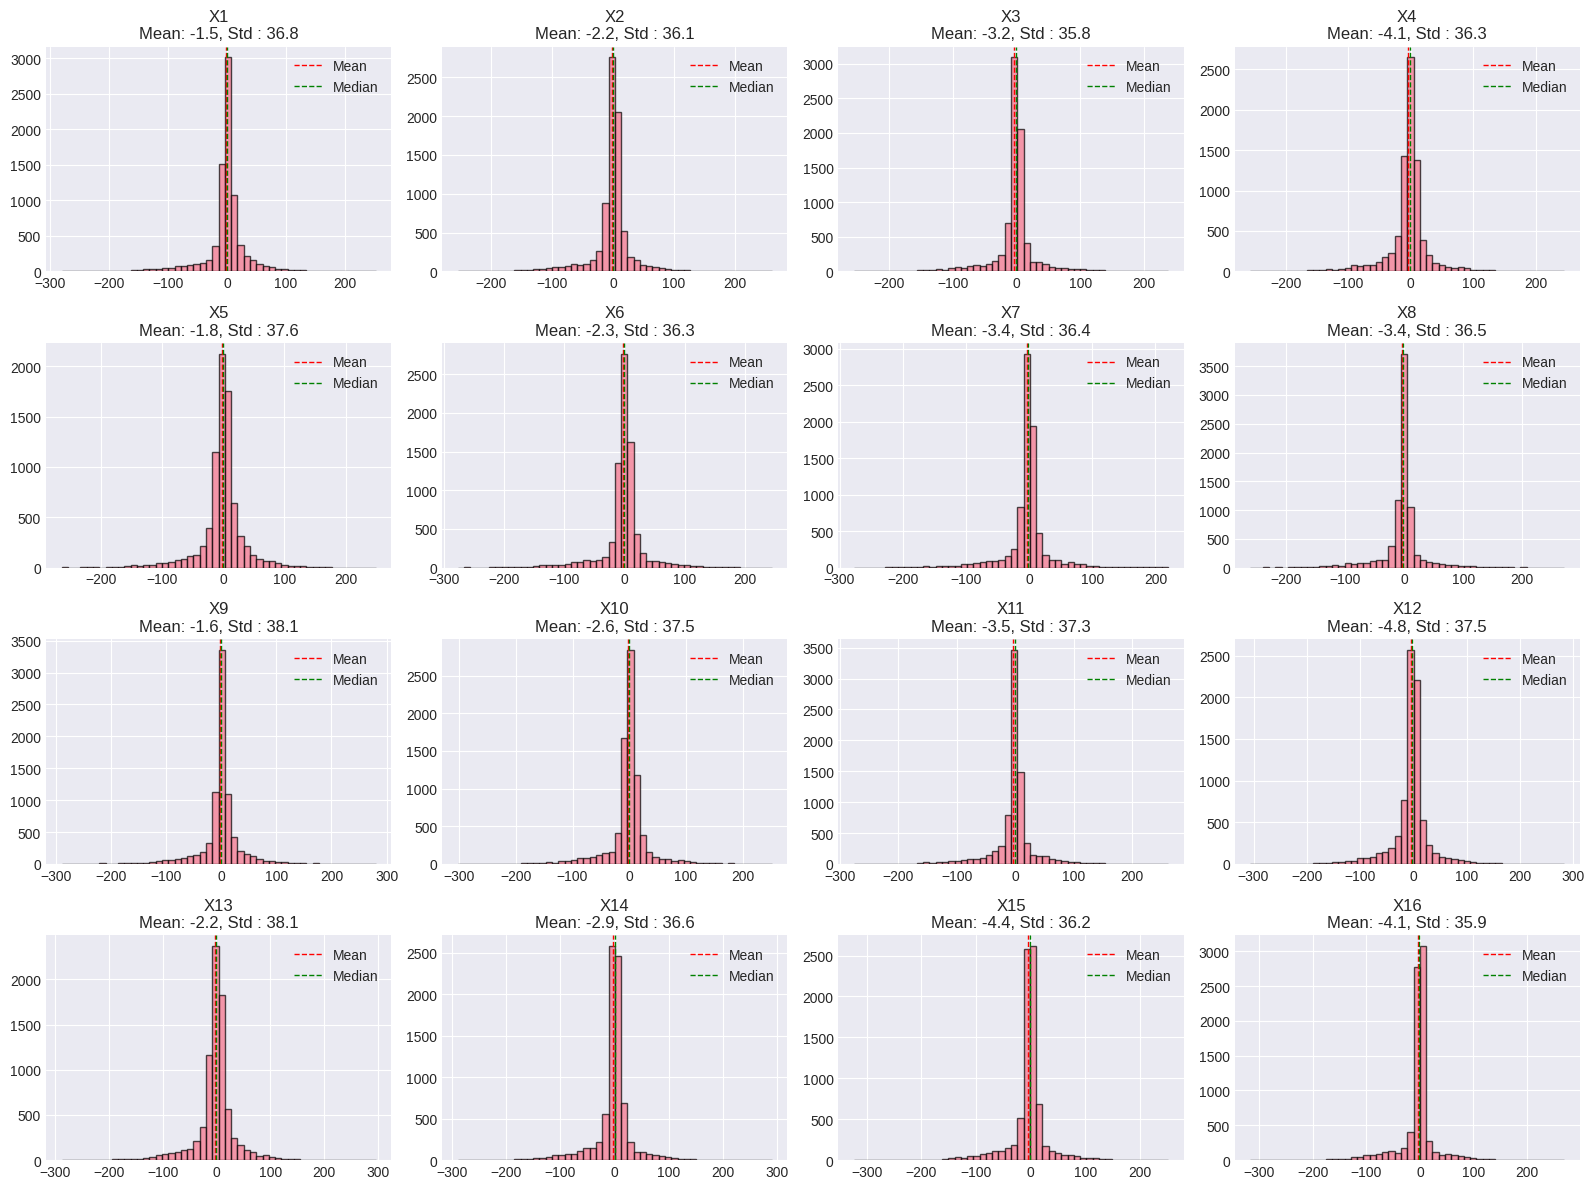

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes  = axes.ravel()

for i, cl in enumerate(df.columns):
    axes[i].hist(df[cl], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{cl}\nMean: {df[cl].mean():.1f}, Std : {df[cl].std():.1f}')
    axes[i].axvline(df[cl].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
    axes[i].axvline(df[cl].median(), color='green', linestyle='--', linewidth=1, label='Median')
    axes[i].legend()

plt.tight_layout()
plt.show()

#### Calculating the Skewness for all Features

In [27]:
skns = df.skew().sort_values()
print(skns)
hSkw = skns[abs(skns) > 1]
if len(hSkw) > 0:
    print(hSkw)

X6    -0.942015
X14   -0.923238
X10   -0.881693
X16   -0.866262
X5    -0.845267
X2    -0.832058
X11   -0.817491
X15   -0.810496
X13   -0.797469
X3    -0.784449
X1    -0.782085
X4    -0.781786
X9    -0.781541
X12   -0.741585
X7    -0.732939
X8    -0.707907
dtype: float64


##### X1, X2, X3, X4 have skewness around -1.5 to -4.1 (negative skew) X5, X6, X7 have skewness around -3.4 to -3.6 (also negative skew)
##### Features like X8, X9, X10 appear to have skewness around -2.2 to -3.6
#### Key observations:
##### All features show negative skew (skewness < 0)
##### Magnitudes are > 1 for many features (highly skewed)
##### Means and medians differ significantly (red vs green lines far apart)
##### This tells us your data is left-skewed - meaning most values cluster on the right side with a long left tail.

#### Correlation HeatMap

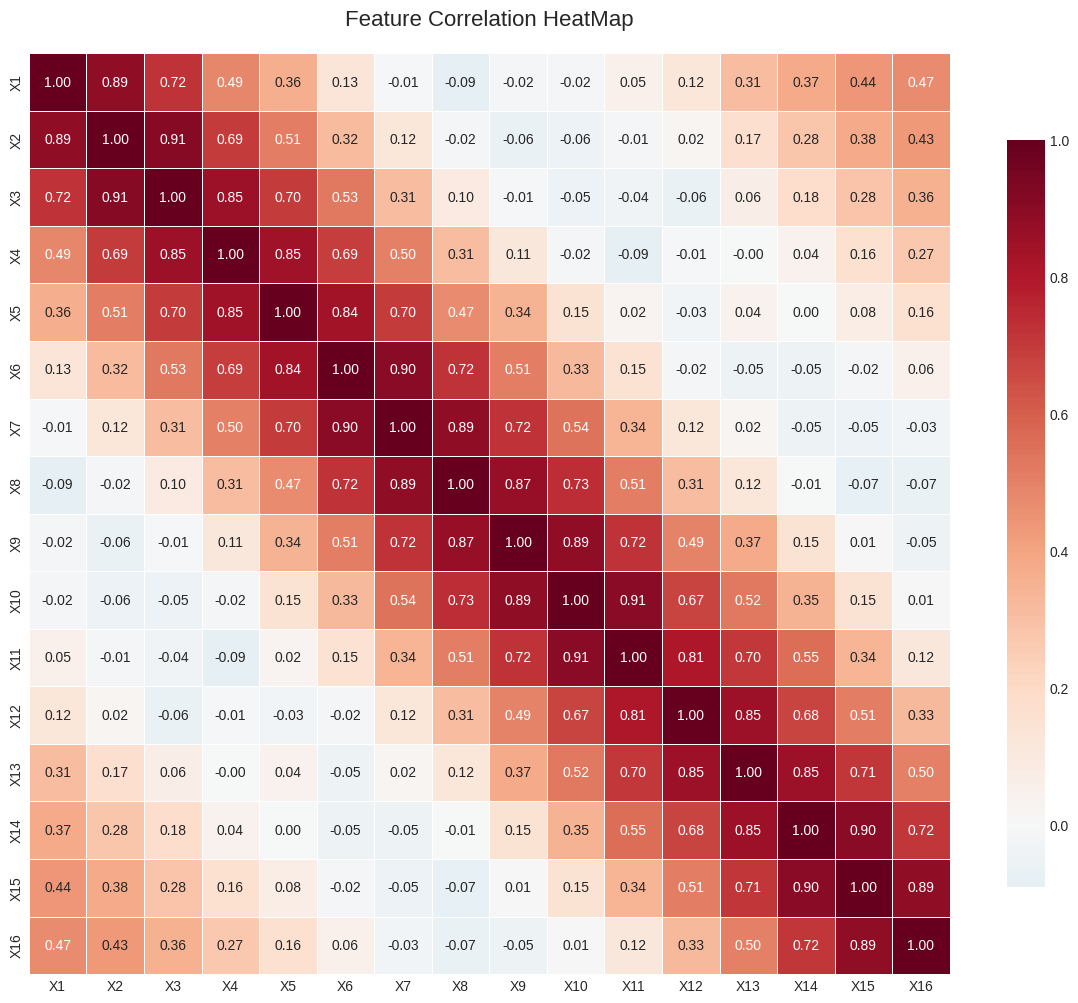

In [29]:
crMat = df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(crMat,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink" : 0.8})
plt.title('Feature Correlation HeatMap', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

#### Highly Correlated Features

In [31]:
hCorr = []
for i in range(len(crMat.columns)):
    for j in range(i+1, len(crMat.columns)):
        crVal = crMat.iloc[i,j]
        if abs(crVal) > 0.9:
            hCorr.append({
                'Feature 1' : crMat.columns[i],
                'Feature 2' : crMat.columns[j],
                'Correlation' : crVal
            })
if hCorr:
    hCrDiff = pd.DataFrame(hCorr)
    print(hCrDiff.to_string(index=False))
else:
    print("No High Corealted Values Found")

Feature 1 Feature 2  Correlation
       X2        X3     0.909936
      X10       X11     0.905474
      X14       X15     0.900052


#### Moderately CoRelated Features

In [32]:
mCorr = []
for i in range(len(crMat.columns)):
    for j in range(i+1, len(crMat.columns)):
        crVal = crMat.iloc[i,j]
        if 0.7 < abs(crVal) <= 0.9:
            mCorr.append({
                'Feature 1' : crMat.columns[i],
                'Feature 2' : crMat.columns[j],
                'Correlation' : crVal
            })

if mCorr:
    mCrDiff = pd.DataFrame(mCorr)
    print(mCrDiff.to_string(index=False))
else:
    print("No Moderate Corelated Values Found")

Feature 1 Feature 2  Correlation
       X1        X2     0.887411
       X1        X3     0.724315
       X3        X4     0.851523
       X4        X5     0.849678
       X5        X6     0.840615
       X6        X7     0.899045
       X6        X8     0.721877
       X7        X8     0.886693
       X7        X9     0.724322
       X8        X9     0.871973
       X8       X10     0.733299
       X9       X10     0.885727
       X9       X11     0.718926
      X11       X12     0.809116
      X11       X13     0.702641
      X12       X13     0.851926
      X13       X14     0.853956
      X13       X15     0.710584
      X14       X16     0.715295
      X15       X16     0.887528
